In [50]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


In [26]:
data = {
    "gender": ["female", "male", "female", "male", "female", "male", "female", "male", "female", "male"],
    "race/ethnicity": ["group B", "group C", "group B", "group D", "group C", "group E", "group A", "group B", "group C", "group D"],
    "parental_level_of_education": [
        "bachelor's degree", "some college", "master's degree", "associate's degree",
        "high school", "some high school", "associate's degree", "bachelor's degree",
        "high school", "some college"
    ],
    "lunch": ["standard", "free/reduced", "standard", "free/reduced", "standard", "standard", "free/reduced", "standard", "free/reduced", "standard"],
    "test_preparation_course": ["none", "completed", "none", "none", "completed", "none", "completed", "completed", "none", "none"],
    "math_score": [72, 69, 90, 47, 76, 56, 40, 88, 52, 61],
    "reading_score": [72, 90, 95, 57, 78, 65, 43, 95, 58, 70],
    "writing_score": [74, 88, 93, 44, 75, 60, 41, 92, 55, 66]
}
df=pd.DataFrame(data)
print(df)

   gender race/ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1    male        group C                some college  free/reduced   
2  female        group B             master's degree      standard   
3    male        group D          associate's degree  free/reduced   
4  female        group C                 high school      standard   
5    male        group E            some high school      standard   
6  female        group A          associate's degree  free/reduced   
7    male        group B           bachelor's degree      standard   
8  female        group C                 high school  free/reduced   
9    male        group D                some college      standard   

  test_preparation_course  math_score  reading_score  writing_score  
0                    none          72             72             74  
1               completed          69             90             88  
2                  

In [27]:
print(df.isna().sum())


gender                         0
race/ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64


In [28]:
df_encoded=pd.get_dummies(df, columns=['gender','race/ethnicity','parental_level_of_education','lunch','test_preparation_course'],drop_first=True)
print(df_encoded)

   math_score  reading_score  writing_score  gender_male  \
0          72             72             74        False   
1          69             90             88         True   
2          90             95             93        False   
3          47             57             44         True   
4          76             78             75        False   
5          56             65             60         True   
6          40             43             41        False   
7          88             95             92         True   
8          52             58             55        False   
9          61             70             66         True   

   race/ethnicity_group B  race/ethnicity_group C  race/ethnicity_group D  \
0                    True                   False                   False   
1                   False                    True                   False   
2                    True                   False                   False   
3                   False      

In [29]:
le=LabelEncoder()
df['gender_encoder']=le.fit_transform(df['gender'])
print(df)

   gender race/ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1    male        group C                some college  free/reduced   
2  female        group B             master's degree      standard   
3    male        group D          associate's degree  free/reduced   
4  female        group C                 high school      standard   
5    male        group E            some high school      standard   
6  female        group A          associate's degree  free/reduced   
7    male        group B           bachelor's degree      standard   
8  female        group C                 high school  free/reduced   
9    male        group D                some college      standard   

  test_preparation_course  math_score  reading_score  writing_score  \
0                    none          72             72             74   
1               completed          69             90             88   
2               

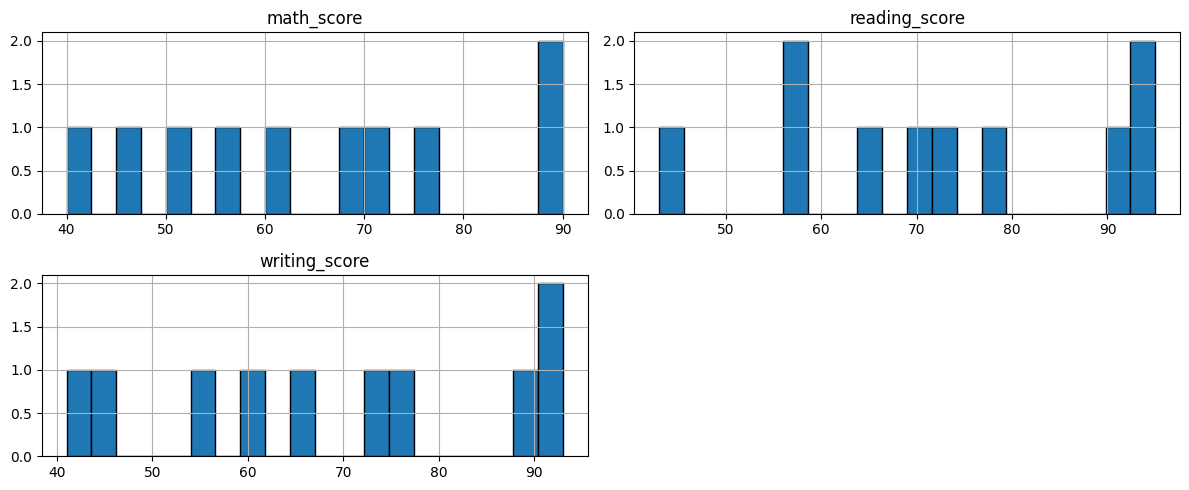

In [30]:
df[['math_score','reading_score','writing_score']].hist(bins=20,figsize=(12,5),edgecolor='black')
plt.title('Distribution of Scores',fontsize=16)
plt.tight_layout()
plt.show()

In [31]:
correlation=df[['math_score','reading_score','writing_score']].corr()
print(correlation)

               math_score  reading_score  writing_score
math_score       1.000000       0.942349       0.951986
reading_score    0.942349       1.000000       0.981404
writing_score    0.951986       0.981404       1.000000


In [37]:
df_encoded['average_score']=df_encoded['math_score']+df_encoded['reading_score']+df_encoded['writing_score']/3
df_encoded['performance']=df_encoded['average_score'].apply(lambda x:'pass' if x>=50 else 'fail')
print(df_encoded)


   math_score  reading_score  writing_score  gender_male  \
0          72             72             74        False   
1          69             90             88         True   
2          90             95             93        False   
3          47             57             44         True   
4          76             78             75        False   
5          56             65             60         True   
6          40             43             41        False   
7          88             95             92         True   
8          52             58             55        False   
9          61             70             66         True   

   race/ethnicity_group B  race/ethnicity_group C  race/ethnicity_group D  \
0                    True                   False                   False   
1                   False                    True                   False   
2                    True                   False                   False   
3                   False      

In [38]:
X=df_encoded.drop(columns=['average_score','performance'])
y=df_encoded['performance']

In [40]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [48]:
model=DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [49]:
y_pred=model.predict(X_test)

In [52]:
print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))

Accuracy:  1.0
Confusion Matrix:
 [[2]]
Classification Report:
               precision    recall  f1-score   support

        pass       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
